In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [5]:
dataset= pd.read_csv(r'C:\Users\ADMIN\Downloads\business.retailsales.csv')


In [6]:
dataset

,Product Type,Net Quantity,Gross Sales,Discounts,Returns,Total Net Sales
0,Art & Sculpture,34,14935.0,-594.00,-1609.00,12732.00
1,Basket,13,3744.0,-316.80,0.00,3427.20
2,Basket,12,3825.0,-201.60,-288.00,3335.40
3,Basket,17,3035.0,-63.25,0.00,2971.75
4,Art & Sculpture,47,2696.8,-44.16,0.00,2652.64
...,...,...,...,...,...,...
1770,Kitchen,0,28.0,-2.81,-25.19,0.00
1771,Jewelry,0,28.0,0.00,-28.00,0.00
1772,Basket,0,116.0,-23.20,-92.80,0.00
1773,Kitchen,0,16.5,0.00,-16.50,0.00


In [10]:
print("\n Dataset Shape:", dataset.shape)
print(dataset.head())
print(dataset.describe())


 Dataset Shape: (1775, 6)
      Product Type  Net Quantity  Gross Sales  Discounts  Returns  \
0  Art & Sculpture            34      14935.0    -594.00  -1609.0   
1           Basket            13       3744.0    -316.80      0.0   
2           Basket            12       3825.0    -201.60   -288.0   
3           Basket            17       3035.0     -63.25      0.0   
4  Art & Sculpture            47       2696.8     -44.16      0.0   

   Total Net Sales  
0         12732.00  
1          3427.20  
2          3335.40  
3          2971.75  
4          2652.64  
       Net Quantity   Gross Sales    Discounts      Returns  Total Net Sales
count   1775.000000   1775.000000  1775.000000  1775.000000      1775.000000
mean       3.712676    199.671746    -6.317623    -5.385437       187.968687
std        6.243078    464.880638    20.903517    46.654269       414.547039
min       -1.000000      0.000000  -594.000000 -1609.000000      -106.250000
25%        1.000000     48.000000    -6.000000 

In [13]:
#Create Target Variable High vs Low Sales
avg_sales = dataset["Total Net Sales"].mean()
dataset["High_Sales"] = (dataset["Total Net Sales"] > avg_sales).astype(int)


In [15]:
print("\nHigh Sales Distribution:\n", dataset["High_Sales"].value_counts())


High Sales Distribution:
 High_Sales
0    1366
1     409
Name: count, dtype: int64


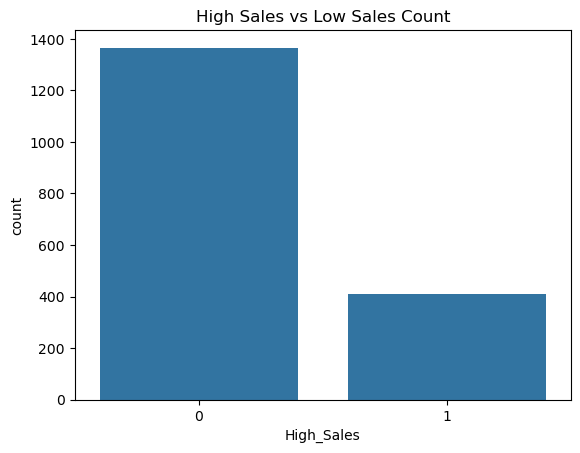

In [17]:
# Visualization
sns.countplot(x="High_Sales", data=dataset)
plt.title("High Sales vs Low Sales Count")
plt.show()


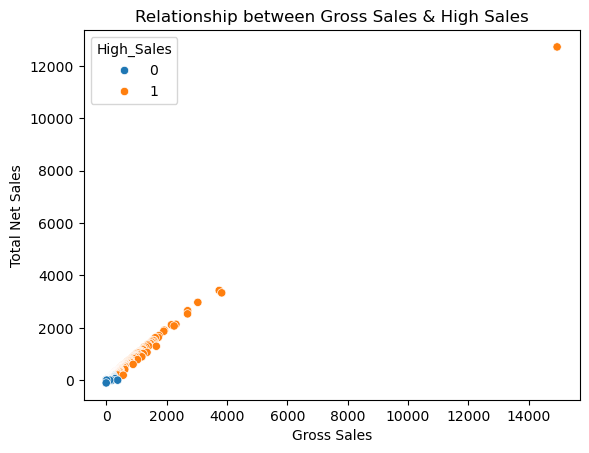

In [25]:
sns.scatterplot(x="Gross Sales", y="Total Net Sales", hue="High_Sales", data=dataset)
plt.title("Relationship between Gross Sales & High Sales")
plt.show()


In [19]:
# (X) and Target (y)
X = dataset[["Net Quantity", "Gross Sales", "Discounts", "Returns"]]
y = dataset["High_Sales"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Logistic Regression Model
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

LogisticRegression()

In [22]:
y_pred = log_model.predict(X_test)

In [28]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.9971830985915493

Confusion Matrix:
 [[276   0]
 [  1  78]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       276
           1       1.00      0.99      0.99        79

    accuracy                           1.00       355
   macro avg       1.00      0.99      1.00       355
weighted avg       1.00      1.00      1.00       355



In [29]:
print("\nModel Coefficients:", log_model.coef_)
print("Model Intercept:", log_model.intercept_)


Model Coefficients: [[-0.07646525  1.20590385  1.17050817  1.11215249]]
Model Intercept: [-226.92173182]
